# Lesson 9 - Video Processing with OpenCV

**Short objective:**
- load video
- inspect video
- extract frames


Video is a sequence of frames.

A frame is one image inside a video.

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request

# Video Loading

In [2]:
import cv2

video = cv2.VideoCapture("wedding.mp4")

if video.isOpened():
    print("Loaded")

Loaded


In [3]:
import cv2

video = cv2.VideoCapture("wedding.mp4")

if not video.isOpened():
    print("Error loading video")
else:
    print("Video loaded successfully")

Video loaded successfully


In [4]:
video_path = r"C:\Users\Rasulbekk\Desktop\Practise\Notebook\wedding.mp4"

In [5]:
video_file = Path(video_path)

if video_file.exists():
    print(f"Video found: {video_file}")
else:
    # Download a small public sample MP4 file.
    sample_url = "https://pixabay.com/videos/butterfly-nature-insect-fauna-345137/"
    print("sample_video.mp4 was not found. Downloading sample video...")
    urllib.request.urlretrieve(sample_url, video_path)
    print(f"Download complete: {video_file}")

Video found: C:\Users\Rasulbekk\Desktop\Practise\Notebook\wedding.mp4


# Biron saytdan video yuklab olish

In [7]:
video_file = Path(video_path)

if video_file.exists():
    print(f"Video found: {video_file}")
else:
    # Download a small public sample MP4 file.
    sample_url = "https://samplelib.com/lib/preview/mp4/sample-5s.mp4"
    print("sample_video.mp4 was not found. Downloading sample video...")
    urllib.request.urlretrieve(sample_url, video_path)
    print(f"Download complete: {video_file}")

Video found: C:\Users\Rasulbekk\Desktop\Practise\Notebook\wedding.mp4


# Frame Extraction

In [9]:
import os

os.makedirs("frames", exist_ok=True)

frame_id = 0

while True:
    ret, frame = video.read()
    
    if not ret:
        break

    if frame_id % 30 == 0:
        cv2.imwrite(f"frames/frame_{frame_id}.jpg", frame)

    frame_id += 1

In [ ]:
#1. Faqat 30- frame saqlanyapti
#2. Yetarlimi model uchun?
    #a. Bazida yaxshi ( tezroq, kam xotira, agar sekin o'zgaruvchan video bolsa)-> Atrofda mashina bormi?
    #b. Bazida yomon(agar tez o'zggaruvchan video bolsa, object faqat malum bir framelarda paydo bolsa, agar detail information kerak bolsa)-> Qachon mashona korindi? 

# Frame Sequences

In [10]:
frames = sorted(os.listdir("frames"))

sequence_length = 5
sequences = []

for i in range(len(frames) - sequence_length):
    seq = frames[i:i+sequence_length]
    sequences.append(seq)

# Umumiy malumot olish

- **total frames**: total number of frames in the video
- **FPS**: frames shown per second
- **width**: frame width in pixels
- **height**: frame height in pixels
- **duration**: video length in seconds

In [11]:
total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
fps = video.get(cv2.CAP_PROP_FPS)
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_seconds = total_frames / fps if fps else 0

print("total_frames:", total_frames)
print("fps:", fps)
print("width:", width)
print("height:", height)
print("duration_seconds:", round(duration_seconds, 2))

total_frames: 394
fps: 24.0
width: 3840
height: 2160
duration_seconds: 16.42


In [14]:
import cv2
from pathlib import Path


output_folder = Path("frames_output")
output_folder.mkdir(parents=True, exist_ok=True)


video = cv2.VideoCapture("wedding.mp4")  


for old_file in output_folder.glob("*.jpg"):
    old_file.unlink()


video.set(cv2.CAP_PROP_POS_FRAMES, 0)

frame_index = 0
saved_count = 0
save_every_n = 30

while True:
    read_success, frame = video.read()

    if not read_success:
        break

    # Har 30-frame ni saqlash
    if frame_index % save_every_n == 0:
        file_name = f"frame_{frame_index:04d}.jpg"
        save_path = output_folder / file_name
        cv2.imwrite(str(save_path), frame)
        saved_count += 1

    frame_index += 1

video.release()

print("Frame extraction complete.")
print("Total frames checked:", frame_index)
print("Saved frames:", saved_count)
print("Saved to folder:", output_folder)

Frame extraction complete.
Total frames checked: 394
Saved frames: 14
Saved to folder: frames_output


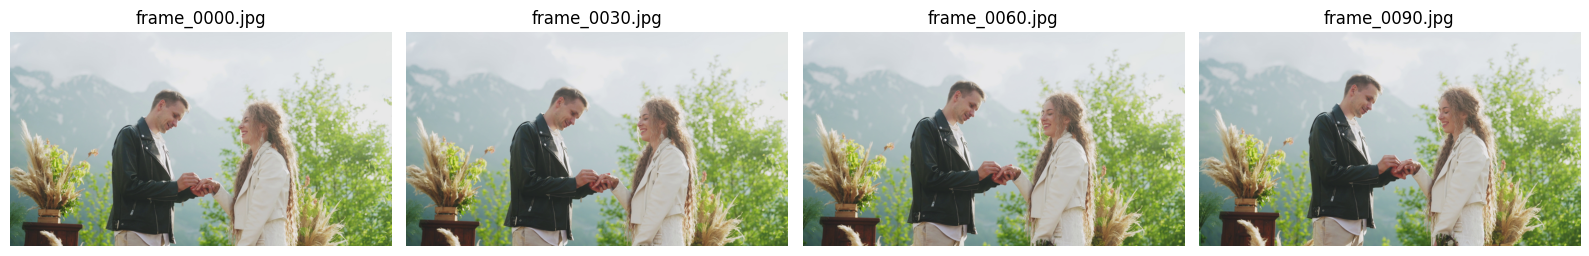

In [15]:
saved_frame_paths = sorted(output_folder.glob("*.jpg"))[:4]

if saved_frame_paths:
    fig, axes = plt.subplots(1, len(saved_frame_paths), figsize=(16, 4))

    if len(saved_frame_paths) == 1:
        axes = [axes]

    for ax, frame_path in zip(axes, saved_frame_paths):
        # Read saved image, then convert BGR to RGB for display.
        image = cv2.imread(str(frame_path))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb)
        ax.set_title(frame_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No saved frames found to display.")

- OpenCV can load video
- Video contains frames
- Frames can be extracted and saved
- This is the first practical step in video processing

In [16]:
video.release()
cv2.destroyAllWindows()
print("Cleanup complete.")

Cleanup complete.
